# *C. elegans* pipeline (demo)

**This notebook is a pipeline demonstration**, not the canonical source for the published figures.  For paper-ready PNG / PDF regeneration of every panel of Fig. 3 and Supp. Figs. 2--5 and 11, use `figures/figure_3.py` and `figures/supp_figure_{2,3,4,5,11}.py`, or run `python figures/run_all.py` from the repository root.

What this notebook does: takes the shipped eigenworm time series, runs the wavelet + PCA + delay-embed + k-means + transition-matrix pipeline, and demonstrates G-PCCA at $M=2$ (Pirouette vs. Run).

In [28]:
# --- Colab / local setup ---
# If you're running on Colab, uncomment the next two lines to install the
# pip dependencies that aren't in the default Colab image (and to clone
# this repo for the helper modules + data).
#
# !pip install pygpcca powerlaw umap-learn
# !git clone https://github.com/<your-org>/slowmode.git
# %cd slowmode

import os, sys, pickle, time
import numpy as np
import matplotlib.pyplot as plt

# Ensure slowmode/ is on the path.
sys.path.insert(0, os.path.abspath('.'))

import pipeline as pp
import gpcca_utils as gu
import figures as fg

fg.setup_style()
os.makedirs('outputs', exist_ok=True)


In [29]:
# --- imports specific to this notebook ---
from sklearn.decomposition import PCA
import warnings; warnings.filterwarnings('ignore', category=UserWarning)


## 1. Load the worm wavelet-PC and eigenworm data

`worms_wlets_pca.pkl` is a list of 12 worms; for each worm, a list of 5
contiguous valid segments (gaps where tracking failed cut the recording);
each segment is a $(T_\mathrm{seg}, 5)$ array of wavelet PCA projections.

`worms_eigenworms.pkl` is a $(386402, 5)$ MaskedArray of eigenworm
coefficients (concatenated time-domain), used for the Panel A power
spectrum and Panel E $\bar{\omega}$ computation.

`worms_state_partitions.pkl` is a $\{worm \to [\text{int arrays}]\}$
dict of cached cluster sequences from $k$-means at $N = 250$.


In [30]:
DATA_DIR = 'data'

# === LOCAL DATA (use this while the Zenodo upload is not yet live) ===
with open(f'{DATA_DIR}/worms_wlets_pca.pkl', 'rb') as f:
    wlets_pca_segments = pickle.load(f)
with open(f'{DATA_DIR}/worms_eigenworms.pkl', 'rb') as f:
    eigenworms = pickle.load(f)
with open(f'{DATA_DIR}/worms_state_partitions.pkl', 'rb') as f:
    states_per_worm = pickle.load(f)

# === ZENODO DATA (after publication, replace the block above with this) ===
# ZENODO_BASE = 'https://zenodo.org/records/<id>/files'
# !mkdir -p data
# !wget -nc {ZENODO_BASE}/worms_wlets_pca.pkl       -P data/
# !wget -nc {ZENODO_BASE}/worms_eigenworms.pkl      -P data/
# !wget -nc {ZENODO_BASE}/worms_state_partitions.pkl -P data/

n_worms = len(wlets_pca_segments)
print(f'{n_worms} worms; segments per worm:'
      f' {[len(wlets_pca_segments[w]) for w in range(n_worms)]}')
print(f'eigenworms shape = {eigenworms.shape}')
print(f'states keys = {sorted(states_per_worm.keys())[:5]}...')


12 worms; segments per worm: [5, 1, 4, 10, 6, 4, 5, 5, 3, 3, 4, 4]
eigenworms shape = (386402, 5)
states keys = [0, 1, 2, 3, 4]...


## 2. Concatenate cluster sequences and build $T(\tau)$

We pool cluster sequences across worms and segments to build a single
$T(\tau)$ at $\tau = 3$ s (48 frames at 16 Hz).


In [31]:
fs = 16.0
tau_seconds = 3.0
lag = int(tau_seconds * fs)            # 48 frames

# Pool all states (the saved partitions are per-worm lists of segments).
all_states = np.concatenate([
    np.asarray(seg, dtype=int)
    for w in sorted(states_per_worm)
    for seg in states_per_worm[w]])
N = int(all_states.max()) + 1
print(f'pooled states: T = {len(all_states)}    N = {N}    lag = {lag} frames')

T_multi = pp.make_transition_matrix(all_states, lag=lag, n_states=N)
pi_multi = pp.stationary_distribution(T_multi)
evals_multi, evecs_multi = pp.leading_eigvecs(T_multi, k=10)
print(f'leading |lambda_k| = {np.abs(evals_multi)[:5].round(4)}')
print(f'spectral gap |lambda_2|/|lambda_3| = '
      f'{np.abs(evals_multi[0]) / np.abs(evals_multi[1]):.3f}')


pooled states: T = 386078    N = 250    lag = 48 frames
leading |lambda_k| = [0.8601 0.7307 0.6776 0.6567 0.6567]
spectral gap |lambda_2|/|lambda_3| = 1.177


## 3. G-PCCA at $M = 2$

The largest spectral gap selects $M = 2$ (run vs pirouette).


In [32]:
out = gu.run_gpcca(T_multi, M=2, eta=pi_multi)
chi = out['chi']                # (N, 2) memberships, descending pi-mass
print(f'crispness     = {out["crispness"]:.3f}')
print(f'basin counts  = {out["basin_counts"]}')
print(f'pi per basin  = {out["pi_basin"].round(3)}')


crispness     = 0.612
basin counts  = [144 106]
pi per basin  = [0.517 0.483]


## Fig. 3A — PSD of the 5 eigenworm coefficients

Power spectral densities of the five eigenworm coefficients across all
worms, with the wavelet-band cutoffs (0.1 and 8 Hz) annotated.


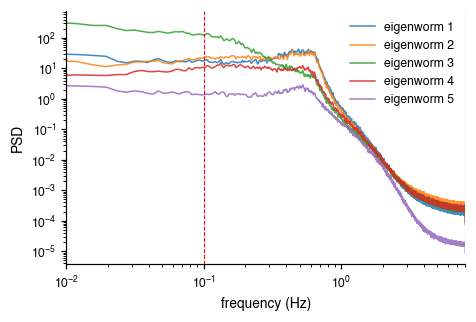

In [33]:
from scipy.signal import welch
ew = np.asarray(eigenworms)
fig, ax = plt.subplots(figsize=(4.4, 3.0))
for k in range(5):
    f, Pxx = welch(ew[:, k], fs=fs, nperseg=4096)
    ax.loglog(f, Pxx, lw=1.0, alpha=0.85, label=f'eigenworm {k+1}')
ax.axvline(0.1, ls='--', color='r', lw=0.7)
ax.axvline(8.0, ls='--', color='r', lw=0.7)
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('PSD')
ax.set_xlim(1e-2, fs / 2)
ax.legend()
plt.tight_layout()
fg.save_panel(fig, 'fig3A_eigenworm_psd')
plt.show()


## Fig. 3B — Eigenvalue spectrum


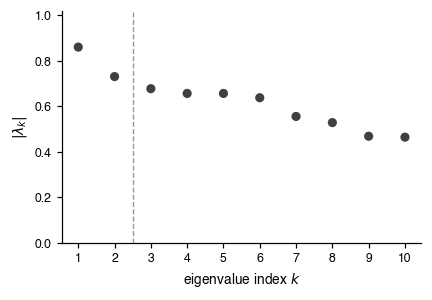

In [34]:
fig, ax = plt.subplots(figsize=(4.0, 2.8))
fg.plot_eigenvalue_dots(ax, evals_multi[:10], M=2)
plt.tight_layout()
fg.save_panel(fig, 'fig3B_eigenvalue_spectrum')
plt.show()


## Fig. 3C / 3D — UMAP-embedded basin enrichment maps

We compute a 2-D UMAP of the per-frame delay-embedded wavelet-PC vectors,
and render the per-bin mean of $\chi_1$ (Fig. 3C: pirouette) and $\chi_2$
(Fig. 3D: run) as RdBu_r heatmaps.

UMAP fitting on ~400 k frames takes a few minutes; for smoothness we sample
60 k frames stratified across worms.


In [16]:
import umap
rng = np.random.default_rng(0)

# Concatenate per-frame wavelet-PC vectors aligned to all_states.
# The cached cluster sequences in worms_state_partitions.pkl come from
# delay-embedded data (d_embed = 7, tau = 1), which loses the first
# (d - 1) = 6 frames of each segment.  Trim the wavelet-PC segments by
# the same amount so the per-frame index matches all_states.
D_EMBED = 7  # must match the d used to build the cached partitions
all_pcs = np.concatenate([
    np.asarray(seg, dtype=float)[D_EMBED - 1:]
    for w in range(n_worms)
    for seg in wlets_pca_segments[w]])
assert len(all_pcs) == len(all_states), (
    f'all_pcs ({len(all_pcs)}) and all_states ({len(all_states)}) misaligned')
print(f'all_pcs.shape = {all_pcs.shape}; aligned to all_states len = {len(all_states)}')

# Sample for the UMAP fit.
N_FIT = 60_000
idx_fit = rng.choice(len(all_pcs), size=N_FIT, replace=False)
um = umap.UMAP(n_neighbors=20, min_dist=0.1, metric='euclidean', random_state=0)
zvals_fit = um.fit_transform(all_pcs[idx_fit])
print(f'UMAP fit on {N_FIT} frames    -> coords {zvals_fit.shape}')
zvals_full = um.transform(all_pcs)     # transform the rest


all_pcs.shape = (386078, 5); aligned to all_states len = 386078


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP fit on 60000 frames    -> coords (60000, 2)


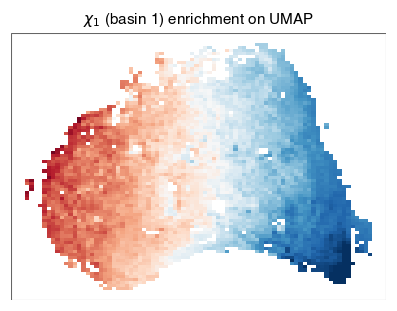

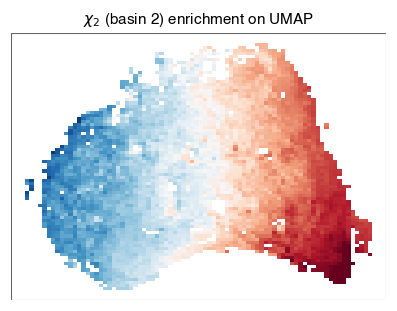

In [17]:
chi_per_frame = chi[all_states]
fig, ax = plt.subplots(figsize=(4.4, 4.4))
fg.plot_density_map(ax, zvals_full[:, 0], zvals_full[:, 1],
                     chi_per_frame[:, 0] - chi[:, 0].mean(),
                     n_bins=80, min_count=20)
ax.set_title(r'$\chi_1$ (basin 1) enrichment on UMAP')
fg.save_panel(fig, 'fig3C_chi1_umap')
plt.show()

fig, ax = plt.subplots(figsize=(4.4, 4.4))
fg.plot_density_map(ax, zvals_full[:, 0], zvals_full[:, 1],
                     chi_per_frame[:, 1] - chi[:, 1].mean(),
                     n_bins=80, min_count=20)
ax.set_title(r'$\chi_2$ (basin 2) enrichment on UMAP')
fg.save_panel(fig, 'fig3D_chi2_umap')
plt.show()


## Fig. 3E — $(\bar{\omega}, |\theta|)$ behavioral plane

Per-cluster scatter on the canonical Costa et al. (2024) behavioral plane
of cluster-mean phase velocity $\bar{\omega}$ and cluster-mean
tangent-angle magnitude $\langle|\theta|\rangle$, colored by basin-1
membership $\chi_1$.  Marker size is proportional to $\pi$.

We compute $\omega(t)$ as the time-derivative of the phase angle in the
(eigenworm-1, eigenworm-2) plane, and $|\theta|$ as the L2 norm of the
five eigenworm coefficients.


In [18]:
# eigenworms is the concatenation of all per-segment eigenworm coefficients.
# We compute omega and |theta| from this 386402-frame array, then trim
# the first (d_embed - 1) = 6 frames of each segment to align with the
# delay-embedded cluster sequences in all_states.
phi = np.arctan2(ew[:, 1], ew[:, 0])
omega_all = np.gradient(np.unwrap(phi)) * fs / (2 * np.pi)  # body waves / s
theta_all = np.abs(ew).mean(axis=1)
print(f'omega in [{omega_all.min():.2f}, {omega_all.max():.2f}] body waves/s')

# Per-segment trim using the wlets_pca segment lengths.
D_EMBED = 7
omega_chunks, theta_chunks = [], []
offset = 0
for w in range(n_worms):
    for seg in wlets_pca_segments[w]:
        L = seg.shape[0]
        omega_chunks.append(omega_all[offset + D_EMBED - 1: offset + L])
        theta_chunks.append(theta_all[offset + D_EMBED - 1: offset + L])
        offset += L
omega = np.concatenate(omega_chunks)
theta_mag = np.concatenate(theta_chunks)
assert len(omega) == len(all_states), (
    f'omega ({len(omega)}) != all_states ({len(all_states)})')

# Average per cluster.
omega_per_cluster = np.zeros(N); theta_per_cluster = np.zeros(N)
counts = np.zeros(N)
np.add.at(omega_per_cluster, all_states, omega)
np.add.at(theta_per_cluster, all_states, theta_mag)
np.add.at(counts, all_states, 1.0)
counts[counts == 0] = 1
omega_per_cluster /= counts
theta_per_cluster /= counts

fig, ax = plt.subplots(figsize=(4.6, 3.6))
sc = ax.scatter(omega_per_cluster, theta_per_cluster,
                 c=chi[:, 0], cmap='RdBu_r', vmin=0, vmax=1,
                 s=300 * pi_multi / pi_multi.max(),
                 edgecolors='k', linewidths=0.3, alpha=0.85)
ax.axvline(0, ls='--', color='0.5', lw=0.7)
ax.set_xlabel(r'cluster mean $\bar{\omega}$ (body waves / s)')
ax.set_ylabel(r'cluster mean $\langle|\theta(s,t)|\rangle$ (rad)')
plt.colorbar(sc, ax=ax, label=r'$\chi_1$')
plt.tight_layout()
fg.save_panel(fig, 'fig3E_omega_theta_plane')
plt.show()


omega in [-4.23, 4.12] body waves/s


ValueError: 
cluster mean $\\bar{\\omega}$ (body waves / s)
             ^
ParseException: Expected end of text, found '$'  (at char 13), (line:1, col:14)

Error in callback <function _draw_all_if_interactive at 0x13355de40> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
cluster mean $\\bar{\\omega}$ (body waves / s)
             ^
ParseException: Expected end of text, found '$'  (at char 13), (line:1, col:14)

ValueError: 
cluster mean $\\bar{\\omega}$ (body waves / s)
             ^
ParseException: Expected end of text, found '$'  (at char 13), (line:1, col:14)

<Figure size 506x396 with 2 Axes>

## Fig. 3F — Survival functions $S(t)$ with power-law fits

Per-basin dwell-time survival $S(t) = P(D > t)$ on log-log axes, with
maximum-likelihood power-law fits via the `powerlaw` package (Clauset et
al., 2009) over $t \in [5, 80]$ s.

The exponents bracket the $\mu = 2$ PDF exponent that Costa et al. (2024)
derive in the strong-modulation limit.


In [ ]:
from powerlaw import Fit

basin_assign = chi.argmax(axis=1)
basin_seq = basin_assign[all_states]

# Compute dwell durations (in seconds) per basin.
def dwell_durations(seq, fs):
    seq = np.asarray(seq, dtype=int)
    edges = np.where(np.diff(seq) != 0)[0]
    if len(edges) < 2: return {0: np.array([]), 1: np.array([])}
    starts = np.r_[0, edges + 1]; ends = np.r_[edges + 1, len(seq)]
    durations = (ends - starts) / fs
    states_dwell = seq[starts]
    return {b: durations[states_dwell == b] for b in [0, 1]}

dwells = dwell_durations(basin_seq, fs)
fig, ax = plt.subplots(figsize=(4.4, 3.2))
colors = ['#0072B2', '#D55E00']
for j, c in enumerate(colors):
    d = dwells[j]
    if len(d) < 50: continue
    ds = np.sort(d); S = 1 - np.arange(len(ds)) / len(ds)
    ax.loglog(ds, S, color=c, lw=1.0, label=f'basin {j+1}')
    fit = Fit(d, xmin=5.0, xmax=80.0, discrete=False)
    alpha = fit.power_law.alpha
    print(f'basin {j+1}: alpha = {alpha:.2f}    n_dwells = {len(d)}')
    tt = np.linspace(5, 80, 50)
    ax.loglog(tt, (tt / 5.0) ** -(alpha - 1) * (1 - np.searchsorted(ds, 5) / len(ds)),
               '--', color=c, lw=0.6)
ax.loglog([5, 80], [0.6, 0.6 * 5/80], ':', color='k', lw=0.6)
ax.set_xlabel('dwell time $t$ (s)'); ax.set_ylabel('$S(t)$')
ax.legend()
plt.tight_layout()
fg.save_panel(fig, 'fig3F_survival_functions')
plt.show()


## Fig. S2 — operator diagnostics

The operator-diagnostic supplementary panels: Cao's $E_1(d)$, the
entropy-gap criterion, eigenvalue spectra (multi vs fixed), and
basin-level non-Markovianity ($r_k(\tau)$ vs lag).

These cells run on the full pooled wavelet-PC array.  Reduce `N_values` or
`max_d` for a faster demo.


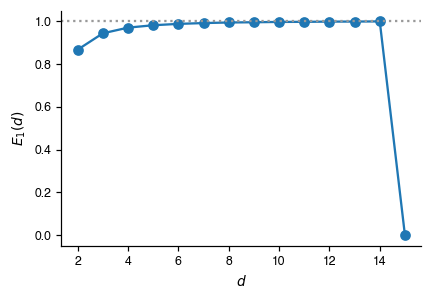

In [35]:
# Fig. S2A: Cao's E_1 on the worm wavelet PCs.
E1 = pp.cao_e1(all_pcs, max_d=15, tau=1, n_samples=20000, seed=0)
fig, ax = plt.subplots(figsize=(4.0, 2.8))
ax.plot(np.arange(2, len(E1) + 2), E1, 'o-', color='C0')
ax.axhline(1.0, ls=':', color='0.6')
ax.set_xlabel(r'$d$'); ax.set_ylabel(r'$E_1(d)$')
plt.tight_layout()
fg.save_panel(fig, 'figS2A_cao_E1')
plt.show()


  N=50: H=59.286  H_shuf=60.671  DeltaH=1.385
  N=100: H=67.758  H_shuf=69.069  DeltaH=1.311
  N=200: H=72.227  H_shuf=72.024  DeltaH=-0.203
  N=400: H=72.351  H_shuf=70.776  DeltaH=-1.574
  N=800: H=66.226  H_shuf=63.586  DeltaH=-2.641


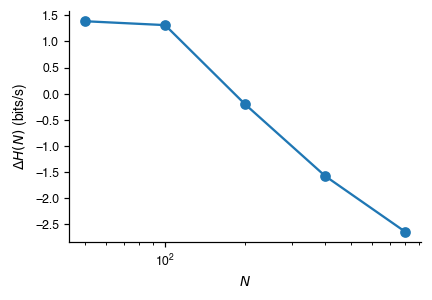

In [36]:
# Fig. S2B: entropy-gap Delta H(N).  Coarse, demo-quality version.
N_values = [50, 100, 200, 400, 800]
X_embed_demo = pp.delay_embed(all_pcs, d=7, tau=1)
Ns, H, Hs = pp.entropy_gap(X_embed_demo[:200000], N_values, lag=lag,
                            framerate=fs, seed=0, n_init=5, verbose=True)
fig, ax = plt.subplots(figsize=(4.0, 2.8))
ax.plot(Ns, Hs - H, 'o-')
ax.set_xscale('log'); ax.set_xlabel('$N$'); ax.set_ylabel(r'$\Delta H(N)$ (bits/s)')
plt.tight_layout()
fg.save_panel(fig, 'figS2B_entropy_gap')
plt.show()


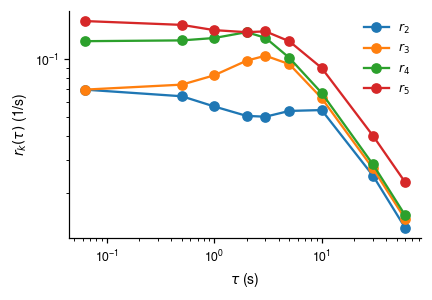

In [37]:
# Fig. S2C: r_k(tau) vs lag for the leading 4 modes.
lags_seconds = np.array([0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 30.0, 60.0])
lags_frames = np.unique((lags_seconds * fs).astype(int))
r_k = np.zeros((len(lags_frames), 4))
for li, lg in enumerate(lags_frames):
    Tk = pp.make_transition_matrix(all_states, lag=int(lg), n_states=N)
    ev, _ = pp.leading_eigvecs(Tk, k=4)
    r_k[li] = -np.log(np.abs(ev[:4])) / (lg / fs)
fig, ax = plt.subplots(figsize=(4.0, 2.8))
for k in range(4):
    ax.plot(lags_frames / fs, r_k[:, k], 'o-', label=f'$r_{{{k+2}}}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\tau$ (s)'); ax.set_ylabel(r'$r_k(\tau)$ (1/s)'); ax.legend()
plt.tight_layout()
fg.save_panel(fig, 'figS2C_basin_non_markovian')
plt.show()


## Fig. S3 — per-worm individuality and Costa per-individual test

We refit G-PCCA on each worm's individual transition matrix, and report
arm-direction cosines vs the pooled fit (a per-worm reproducibility test).
The aggregated $\sigma_\mathrm{slow}$ vs $\alpha$ correlation per worm
is the worm-side equivalent of Fig. 5D for flies, and it is null at
$n = 12$ — consistent with the manuscript's "limited number of slowest-
timescale transitions per worm" attribution.


worm 1: GPCCA failed (Not all elements of eta are > 0. The smallest element is 0.0)
worm 5: GPCCA failed (Input matrix P is not a transition matrix.)
worm 6: GPCCA failed (Input matrix P is not a transition matrix.)
worm 11: GPCCA failed (Not all elements of eta are > 0. The smallest element is 0.0)


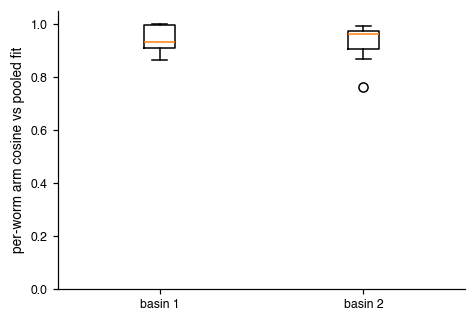

median cosines: [0.93247583 0.96310802]


In [38]:
# Per-worm refit: rebuild T(tau) on each worm's own cluster sub-sequence,
# rerun G-PCCA, and match the resulting arm directions to the pooled fit by
# best 2x2 cosine pairing.  Per-individual sequences only visit a subset of
# the N=250 global clusters, so we restrict T to the visited subset before
# G-PCCA (full-N T has empty rows / vanishing stationary mass for unvisited
# clusters, which pyGPCCA rejects).
arm_dirs_pool = gu.compute_hub_arms(evecs_multi[:, :2].real, pi_multi, chi)['arm_dirs']

cos_per_worm = []
for w in sorted(states_per_worm):
    states_w = np.concatenate([np.asarray(s, dtype=int)
                               for s in states_per_worm[w]])
    if len(states_w) < lag * 4: continue

    # Restrict to visited clusters.
    visited = np.unique(states_w)
    remap = -np.ones(N, dtype=int); remap[visited] = np.arange(len(visited))
    states_w_r = remap[states_w]
    Tw = pp.make_transition_matrix(states_w_r, lag=lag, n_states=len(visited))
    pi_w = pp.stationary_distribution(Tw)
    try:
        out_w = gu.run_gpcca(Tw, M=2, eta=pi_w)
    except Exception as e:
        print(f'worm {w}: GPCCA failed ({e})'); continue
    ev_w, vc_w = pp.leading_eigvecs(Tw, k=2)
    arms_w = gu.compute_hub_arms(vc_w[:, :2].real, pi_w, out_w['chi'])['arm_dirs']

    # 2-basin best matching: try both pairings, take the larger cosine sum.
    c00 = abs(arms_w[0] @ arm_dirs_pool[0]); c11 = abs(arms_w[1] @ arm_dirs_pool[1])
    c01 = abs(arms_w[0] @ arm_dirs_pool[1]); c10 = abs(arms_w[1] @ arm_dirs_pool[0])
    if c00 + c11 >= c01 + c10:
        cos_per_worm.append([c00, c11])
    else:
        cos_per_worm.append([c01, c10])
cos_per_worm = np.array(cos_per_worm)

fig, ax = plt.subplots(figsize=(4.4, 3.0))
ax.boxplot(cos_per_worm, labels=['basin 1', 'basin 2'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('per-worm arm cosine vs pooled fit')
plt.tight_layout()
fg.save_panel(fig, 'figS3_per_worm_arm_cosines')
plt.show()
print('median cosines:', np.median(cos_per_worm, axis=0))


---

All worm panels are saved as PNG/PDF under `outputs/`. Continue to
`flies.ipynb` for the load-bearing fly methodology and biology figures.
